In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [6]:
data = sm.datasets.stackloss.load()
df = data.data
print(data.names)

['STACKLOSS', 'AIRFLOW', 'WATERTEMP', 'ACIDCONC']


In [17]:
y = df['STACKLOSS']
X = df[['AIRFLOW', 'WATERTEMP', 'ACIDCONC']]
X1 = df['AIRFLOW']
X2 = df['WATERTEMP']
X3 = df['ACIDCONC']

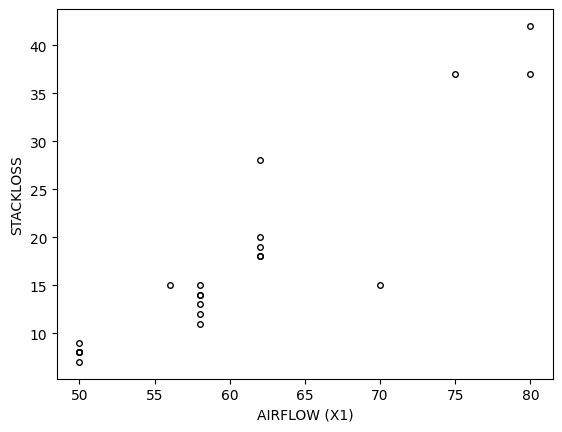

In [13]:
plt.plot(X1, y, 'o', markersize=4, fillstyle='none', color='black')
plt.ylabel("STACKLOSS")
plt.xlabel("AIRFLOW (X1)")
plt.show()

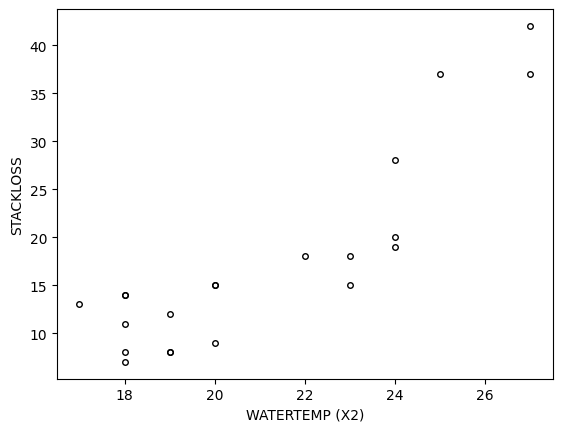

In [16]:
plt.plot(X2, y, 'o', markersize=4, fillstyle='none', color='black')
plt.ylabel("STACKLOSS")
plt.xlabel("WATERTEMP (X2)")
plt.show()

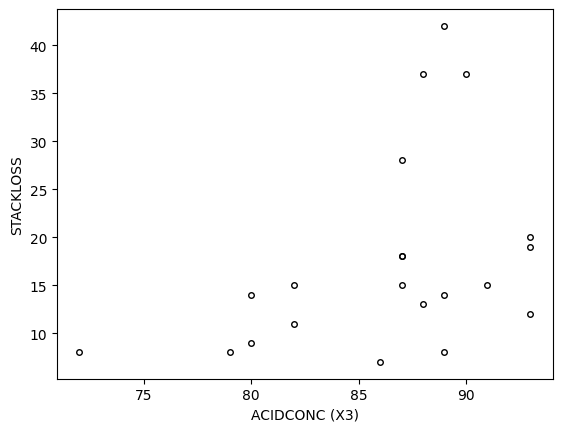

In [15]:
plt.plot(X3, y, 'o', markersize=4, fillstyle='none', color='black')
plt.ylabel("STACKLOSS")
plt.xlabel("ACIDCONC (X3)")
plt.show()

In [18]:
X_sm = sm.add_constant(X)

model = sm.OLS(y, X_sm).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              STACKLOSS   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.898
Method:                 Least Squares   F-statistic:                     59.90
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           3.02e-09
Time:                        00:52:28   Log-Likelihood:                -52.288
No. Observations:                  21   AIC:                             112.6
Df Residuals:                      17   BIC:                             116.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -39.9197     11.896     -3.356      0.0

In [21]:
confidence_intervals = model.conf_int(alpha=0.1)

print(confidence_intervals)

                   0          1
const     -60.614031 -19.225318
AIRFLOW     0.481040   0.950240
WATERTEMP   0.655069   1.935504
ACIDCONC   -0.424013   0.119768


In [22]:
X_new = np.array([1, 58, 20, 86])
pred = model.get_prediction(X_new)
print(pred.summary_frame(alpha=0.01))

        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  14.410643  0.754001      12.225373      16.595913      4.759959   

   obs_ci_upper  
0     24.061327  
